In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# Reading AI Datacenter locations, filtering out to get active datacenters
datacenters = pd.read_csv('ai_data_centers_consumption_and_locations.csv')

datacenters = datacenters[(datacenters['Country']=='United States') & (datacenters['Current power (MW)'] > 0)]
datacenters['State'] = datacenters['County'].str.split(', ').str[1]
datacenters['County'] = datacenters['County'].str.split(',').str[0]
datacenters.drop(columns = ['Current H100 equivalents',
                            'Current total capital cost (2025 USD billions)',
                            'Owner', 'Users', 'Selected Sources', 'Calculations sheet',
                            'Project', 'Current chip types', 'All chip types', 'Investors',
                            'Construction companies', 'Energy companies', 'Country','Address'], inplace = True)

datacenters_by_county = datacenters.groupby(['County','State']).agg(
    num_datacenters = ('Current power (MW)', 'count'),
    total_power_consumption_mw = ('Current power (MW)', 'sum')
    )
datacenters_by_county = datacenters_by_county.reset_index()
datacenters_by_county['County'] = datacenters_by_county['County'].str.replace(' County', '').str.strip()

# per relavent county, find utility number id
county_to_utility = pd.read_excel('eia861/f8612024/Service_Territory_2024.xlsx', sheet_name='Counties_States')[['State', 'County', 'Utility Number']].drop_duplicates()
county_to_utility['State'] = county_to_utility['State'].str.strip()
county_to_utility['County'] = county_to_utility['County'].str.strip()
df_master = datacenters_by_county.merge(county_to_utility, on=['State', 'County'], how='left')

# loop through past 7 years and obtain residential rates per county using EIA861
year_range = range(2018, 2025)
price_columns = []
for year in year_range:
    file_path = f'eia861/f861{year}/Sales_Ult_Cust_{year}.xlsx'
    df_sales = pd.read_excel(file_path, sheet_name='States', header=2)

    # calculate the residential price, keep only prices associated with physical infrastructure
    df_sales['Megawatthours'] = pd.to_numeric(df_sales['Megawatthours'], errors='coerce')
    df_sales['Thousand Dollars'] = pd.to_numeric(df_sales['Thousand Dollars'], errors='coerce')
    df_sales = df_sales[df_sales['Part'].isin(['A', 'C']) & (df_sales['Megawatthours'] > 0)].copy()
    price_col = f'Price_{year}_MWh'
    price_columns.append(price_col)
    df_sales[price_col] = (df_sales['Thousand Dollars'] * 1000) / df_sales['Megawatthours']
    
    # Average the price per utility provider and put back into df_master
    utility_prices = df_sales.groupby(['Utility Number', 'State'])[price_col].mean().reset_index()
    df_master = df_master.merge(utility_prices, on=['Utility Number', 'State'], how='left')

# recreate final dataframe, averaging utilities providing the same county in the same year
final_treatment_group = (df_master
                         .groupby(['County', 'State', 'num_datacenters', 'total_power_consumption_mw'])[price_columns]
                         .mean()
                         .reset_index()
                         .sort_values(by=['num_datacenters', 'total_power_consumption_mw'], ascending=[False, False]))

final_treatment_group

,County,State,num_datacenters,total_power_consumption_mw,Price_2018_MWh,Price_2019_MWh,Price_2020_MWh,Price_2021_MWh,Price_2022_MWh,Price_2023_MWh,Price_2024_MWh
23,Licking,OH,3,1108.00000,120.697184,122.216094,123.445555,129.365480,135.792983,144.718781,153.825718
20,Henrico,VA,3,562.00000,116.616409,120.564580,121.796104,121.302996,134.097218,139.159278,140.943315
27,Maricopa,AZ,3,449.00000,124.665840,116.492391,119.429844,120.106086,129.796982,142.221692,161.162755
2,Bexar,TX,3,154.00000,104.769760,104.154616,103.719821,109.831167,116.123924,118.564396,118.883099
35,Shelby,TN,2,1286.00000,96.607301,100.343841,100.204066,106.011470,119.678436,115.637846,121.620441
26,Madison,MS,2,512.00000,98.204495,99.906743,97.312818,103.852871,116.164758,136.233962,132.137219
32,Prince William,VA,2,323.00000,118.230214,122.928250,118.515720,120.942930,133.452618,139.160234,128.323324
34,Sarpy,NE,2,317.00000,112.089316,113.004463,113.963125,113.845879,116.797934,120.182381,123.578616
15,Ellis,TX,2,180.00000,99.807198,100.390313,98.160355,113.454921,145.429753,146.978711,140.539541
30,Niagara,NY,2,100.00000,97.284138,96.073098,98.926690,109.165425,124.721244,124.886005,141.432192


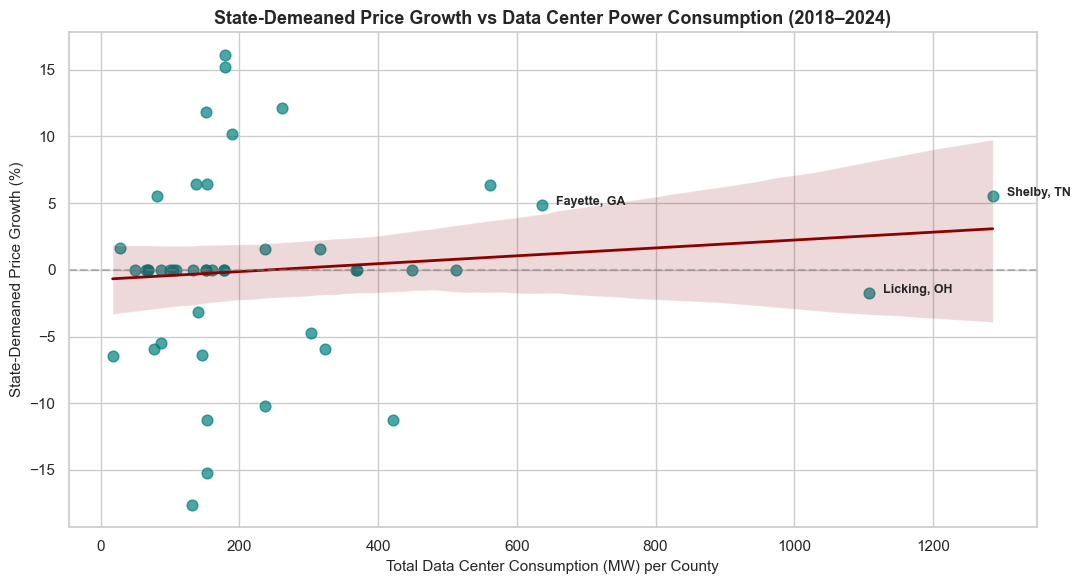

In [53]:
final_treatment_group['Price_Growth_Pct'] = (
    (final_treatment_group['Price_2024_MWh'] - final_treatment_group['Price_2018_MWh']) 
    / final_treatment_group['Price_2018_MWh']
) * 100

final_treatment_group['Growth_Demeaned'] = (
    final_treatment_group['Price_Growth_Pct'] 
    - final_treatment_group.groupby('State')['Price_Growth_Pct'].transform('mean')
)

plot_df = final_treatment_group.dropna(subset=['Growth_Demeaned', 'total_power_consumption_mw'])

plt.figure(figsize=(11, 6))
sns.regplot(
    data=plot_df, 
    x='total_power_consumption_mw', 
    y='Growth_Demeaned', 
    scatter_kws={'alpha': 0.7, 'color': 'teal', 's': 60}, 
    line_kws={'color': 'darkred', 'linewidth': 2}
)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('State-Demeaned Price Growth vs Data Center Power Consumption (2018–2024)', fontsize=13, fontweight='bold')
plt.xlabel('Total Data Center Consumption (MW) per County', fontsize=11)
plt.ylabel('State-Demeaned Price Growth (%)', fontsize=11)

top_counties = plot_df.nlargest(3, 'total_power_consumption_mw')
for _, row in top_counties.iterrows():
    plt.text(
        row['total_power_consumption_mw'] + 20, 
        row['Growth_Demeaned'], 
        f"{row['County']}, {row['State']}", 
        fontsize=9, weight='bold'
    )

plt.tight_layout()
plt.show()